# Project 3: Fashion Product Image Categorizer - Step 1: CV Classification Pipeline

This notebook implements a classical computer vision pipeline to classify clothing products from the Fashion-MNIST dataset.

## Blueprint Actions Covered
* **Image Preprocessing**: Normalize pixel values, reshape and downsample/resize images, and flatten back to 1D vectors.
* **Dimensionality Reduction**: Apply Principal Component Analysis (PCA) to compress pixel dimensions while retaining variance.
* **Classification**: Train and optimize Support Vector Classifier (SVC) and k-Nearest Neighbors (kNN) models to categorize products.

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import skimage.transform
import joblib
import warnings
warnings.filterwarnings('ignore')

# Paths to Fashion-MNIST CSV dataset files
TRAIN_CSV = "../datasets/fashion-mnist/fashion-mnist_train.csv"
TEST_CSV = "../datasets/fashion-mnist/fashion-mnist_test.csv"

print(f"Train file exists: {os.path.exists(TRAIN_CSV)}")
print(f"Test file exists:  {os.path.exists(TEST_CSV)}")

Train file exists: True
Test file exists:  True


## 1. Data Ingestion & Stratified Downsampling

We load the Fashion-MNIST CSV files and downsample them to stratified subsets (10,000 train, 2,000 test) to optimize SVM and kNN training times on CPU while ensuring fair class representation.

In [7]:
print("Loading raw Fashion-MNIST datasets...")
df_train_raw = pd.read_csv(TRAIN_CSV)
df_test_raw = pd.read_csv(TEST_CSV)

print(f"Raw train shape: {df_train_raw.shape}")
print(f"Raw test shape:  {df_test_raw.shape}")

# Perform stratified downsampling
df_train_sampled, _ = train_test_split(
    df_train_raw, 
    train_size=10000, 
    stratify=df_train_raw['label'], 
    random_state=42
)

df_test_sampled, _ = train_test_split(
    df_test_raw, 
    train_size=2000, 
    stratify=df_test_raw['label'], 
    random_state=42
)

# Separate features and labels
X_train_raw = df_train_sampled.drop(columns=['label']).values
y_train = df_train_sampled['label'].values

X_test_raw = df_test_sampled.drop(columns=['label']).values
y_test = df_test_sampled['label'].values

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"\nDownsampled train shape: X = {X_train_raw.shape}, y = {y_train.shape}")
print(f"Downsampled test shape:  X = {X_test_raw.shape}, y = {y_test.shape}")
print("Class distribution in training subset:", np.bincount(y_train))

Loading raw Fashion-MNIST datasets...
Raw train shape: (60000, 785)
Raw test shape:  (10000, 785)

Downsampled train shape: X = (10000, 784), y = (10000,)
Downsampled test shape:  X = (2000, 784), y = (2000,)
Class distribution in training subset: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


## 2. Visual Exploration & EDA

We reshape the flat vectors to 2D image matrices and visualize one representative sample for each of the 10 clothing categories.

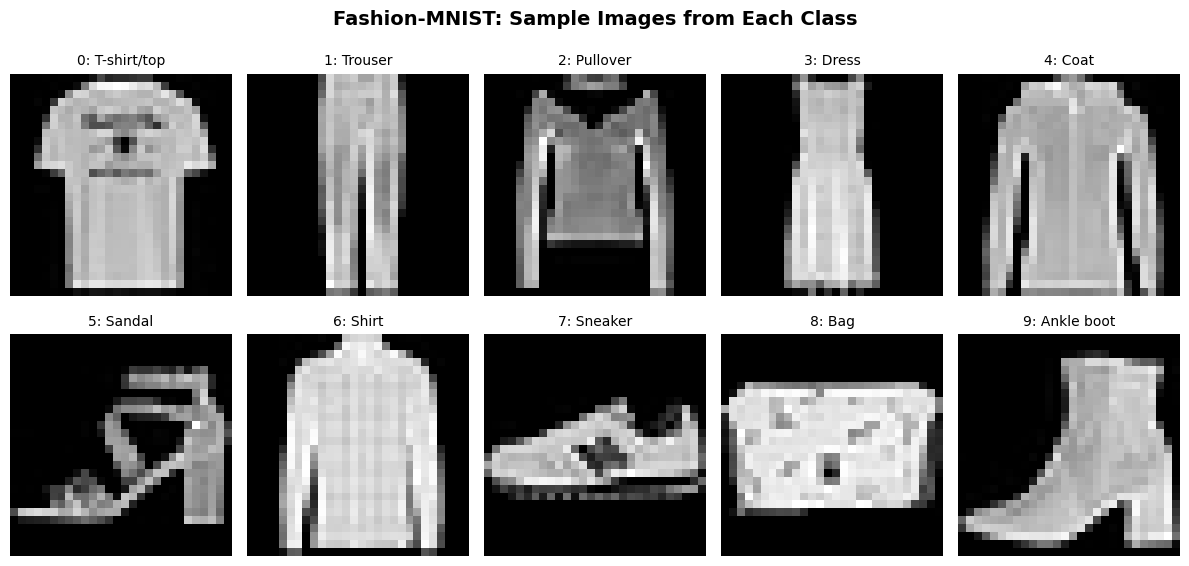

In [8]:
# Find first sample of each class
sample_indices = [np.where(y_train == i)[0][0] for i in range(10)]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for idx, class_id in enumerate(range(10)):
    sample_idx = sample_indices[class_id]
    img = X_train_raw[sample_idx].reshape(28, 28)
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{class_id}: {class_names[class_id]}", fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Fashion-MNIST: Sample Images from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
PLOT_DIR = "../../reports/figures/fashion_classifier"
os.makedirs(PLOT_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOT_DIR, "01_sample_class_grid.png"), dpi=150)
plt.show()

## 3. Image Preprocessing Pipeline

We define a processing function that normalizes pixel intensities, reshapes to 2D, resizes to a lower 14x14 resolution (the "Resize" blueprint requirement), and flattens back into a 1D vector of length 196.

Preprocessing training and test images...
Preprocessed train shape: (10000, 196)
Preprocessed test shape:  (2000, 196)


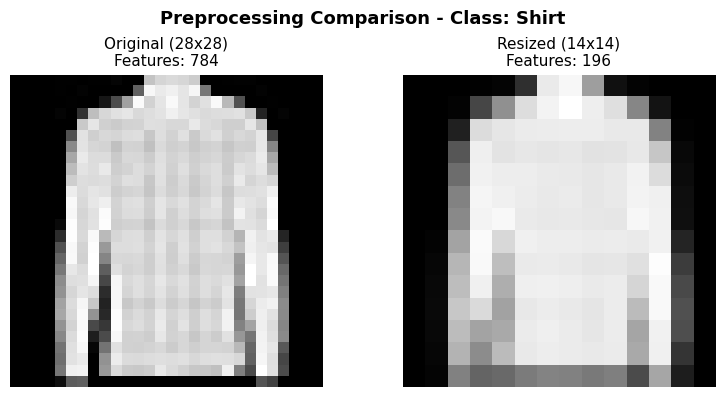

In [9]:
def preprocess_images(images, target_size=(14, 14)):
    # 1. Normalize pixel values
    normalized = images / 255.0
    
    preprocessed = []
    for img_flat in normalized:
        # 2. Reshape to 2D image matrix
        img_2d = img_flat.reshape(28, 28)
        # 3. Resize using anti-aliasing
        img_resized = skimage.transform.resize(img_2d, target_size, anti_aliasing=True)
        # 4. Flatten back to 1D
        preprocessed.append(img_resized.flatten())
        
    return np.array(preprocessed)

print("Preprocessing training and test images...")
X_train_preprocessed = preprocess_images(X_train_raw)
X_test_preprocessed = preprocess_images(X_test_raw)

print(f"Preprocessed train shape: {X_train_preprocessed.shape}")
print(f"Preprocessed test shape:  {X_test_preprocessed.shape}")

# Visualize original vs. preprocessed image comparison
original_img = (X_train_raw[0] / 255.0).reshape(28, 28)
resized_img = X_train_preprocessed[0].reshape(14, 14)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f"Original (28x28)\nFeatures: 784", fontsize=11)
axes[0].axis('off')

axes[1].imshow(resized_img, cmap='gray')
axes[1].set_title(f"Resized (14x14)\nFeatures: 196", fontsize=11)
axes[1].axis('off')

plt.suptitle(f"Preprocessing Comparison - Class: {class_names[y_train[0]]}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_preprocessing_comparison.png"), dpi=150)
plt.show()

## 4. Dimensionality Reduction (PCA)

We fit PCA to identify the minimum number of principal components needed to explain 95% of cumulative variance. We then transform our features and plot a 2D projection along with the visual representations of the principal component weights ("eigenimages").

Analyzing PCA explained variance...


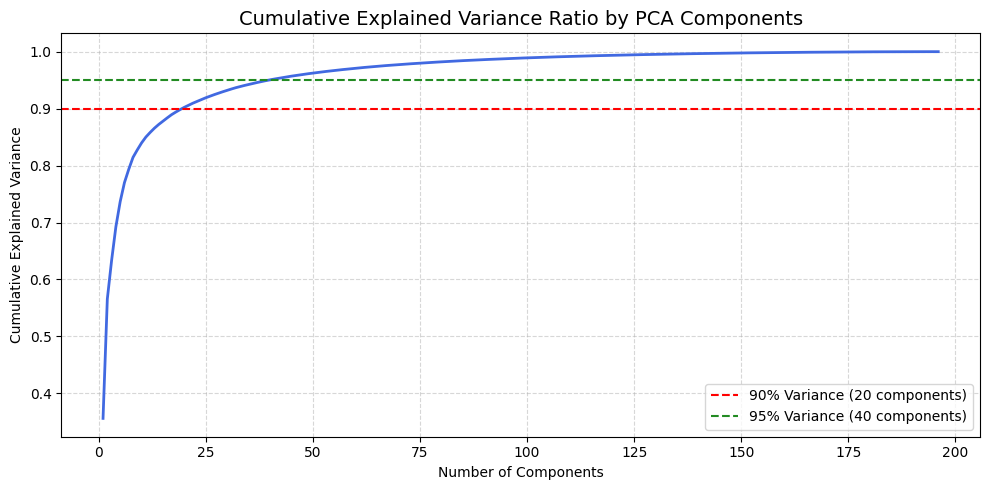

Number of components to preserve 90% variance: 20
Number of components to preserve 95% variance: 40

PCA transformation complete. Features reduced from 196 to 40.


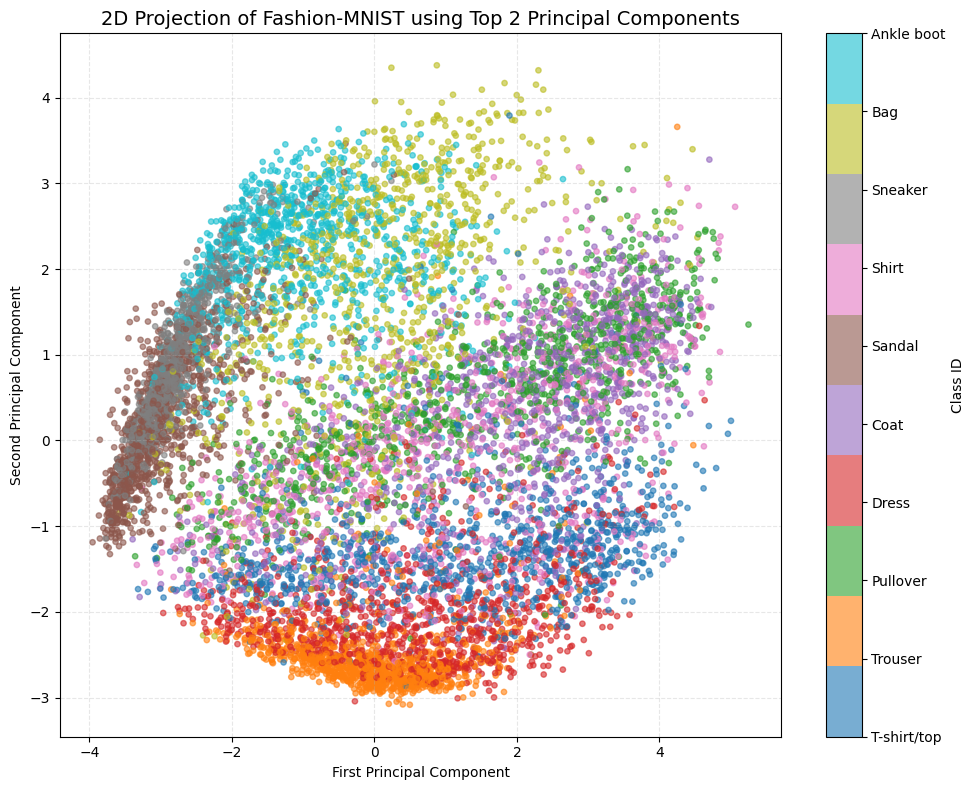

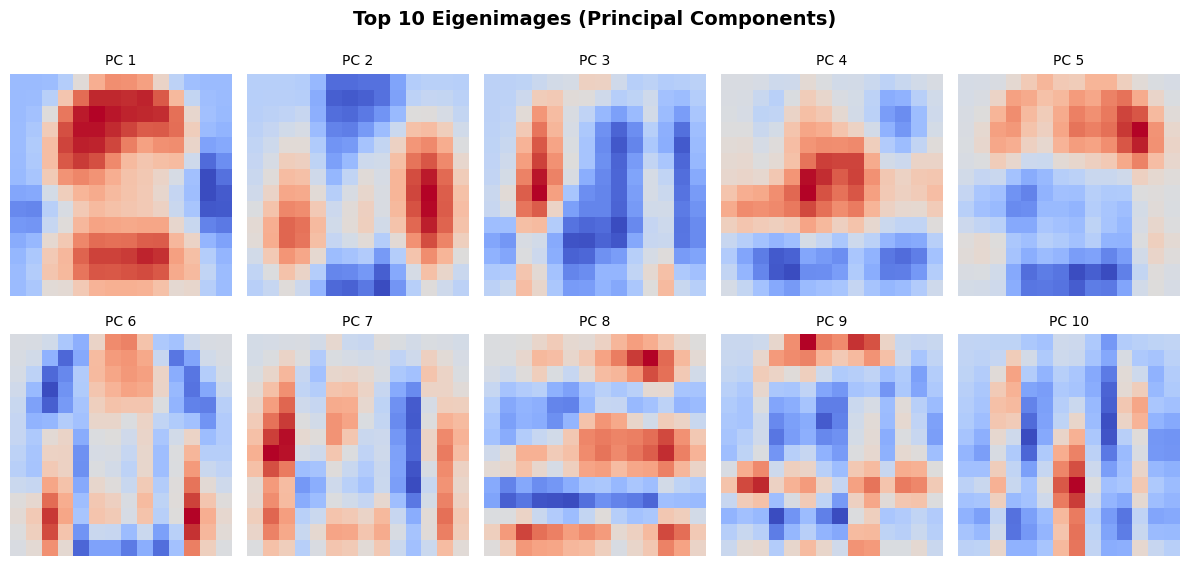

In [13]:
print("Analyzing PCA explained variance...")
pca_temp = PCA(random_state=42)
pca_temp.fit(X_train_preprocessed)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color='royalblue', lw=2)
plt.axhline(y=0.90, color='red', linestyle='--', label=f'90% Variance ({n_components_90} components)')
plt.axhline(y=0.95, color='forestgreen', linestyle='--', label=f'95% Variance ({n_components_95} components)')
plt.title("Cumulative Explained Variance Ratio by PCA Components", fontsize=14)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_pca_variance_plot.png"), dpi=150)
plt.show()

print(f"Number of components to preserve 90% variance: {n_components_90}")
print(f"Number of components to preserve 95% variance: {n_components_95}")

# Re-fit PCA targeting 95% variance
n_components = n_components_95
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_preprocessed)
X_test_pca = pca.transform(X_test_preprocessed)

print(f"\nPCA transformation complete. Features reduced from {X_train_preprocessed.shape[1]} to {X_train_pca.shape[1]}.")

# Visualize 2D projection scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, ticks=range(10), label="Class ID").set_ticklabels(class_names)
plt.title("2D Projection of Fashion-MNIST using Top 2 Principal Components", fontsize=14)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_pca_2d_scatter.png"), dpi=150)
plt.show()


# Plot top 10 Eigenimages
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()
for idx in range(10):
    eigenimage = pca.components_[idx].reshape(14, 14)
    axes[idx].imshow(eigenimage, cmap='coolwarm')
    axes[idx].set_title(f"PC {idx+1}", fontsize=10)
    axes[idx].axis('off')
plt.suptitle("Top 10 Eigenimages (Principal Components)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_pca_eigenimages.png"), dpi=150)
plt.show()

## 5. Model Training & Hyperparameter Tuning

We define candidate parameter grids and run parallelized `GridSearchCV` to locate optimal configurations for both our **Support Vector Classifier (SVC)** and **k-Nearest Neighbors (kNN)** models.

In [6]:
# 1. Support Vector Classifier (SVC) Grid Search
print("Tuning Support Vector Classifier (SVC)...")
svc_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}
svc_grid = GridSearchCV(SVC(random_state=42), svc_param_grid, cv=3, n_jobs=-1, scoring='accuracy')
start_time = time.time()
svc_grid.fit(X_train_pca, y_train)
svc_time = time.time() - start_time
print(f"SVC Best Params: {svc_grid.best_params_}")
print(f"SVC Best Cross-Val Accuracy: {svc_grid.best_score_:.4f}")
print(f"SVC Tuning Time: {svc_time:.2f} seconds")

# 2. k-Nearest Neighbors (kNN) Grid Search
print("\nTuning k-Nearest Neighbors (kNN)...")
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=3, n_jobs=-1, scoring='accuracy')
start_time = time.time()
knn_grid.fit(X_train_pca, y_train)
knn_time = time.time() - start_time
print(f"kNN Best Params: {knn_grid.best_params_}")
print(f"kNN Best Cross-Val Accuracy: {knn_grid.best_score_:.4f}")
print(f"kNN Tuning Time: {knn_time:.2f} seconds")

Tuning Support Vector Classifier (SVC)...


SVC Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVC Best Cross-Val Accuracy: 0.8630
SVC Tuning Time: 42.24 seconds

Tuning k-Nearest Neighbors (kNN)...


kNN Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
kNN Best Cross-Val Accuracy: 0.8226
kNN Tuning Time: 6.53 seconds


## 6. Model Evaluation & Comparison

We evaluate our best estimators on our unseen test split. We inspect precision, recall, and F1 metrics per product category and draw comparative metrics.

SUPPORT VECTOR CLASSIFIER (SVC) TEST EVALUATION
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.88      0.83       200
     Trouser       0.98      0.96      0.97       200
    Pullover       0.81      0.81      0.81       200
       Dress       0.83      0.91      0.87       200
        Coat       0.80      0.84      0.82       200
      Sandal       0.95      0.95      0.95       200
       Shirt       0.79      0.61      0.69       200
     Sneaker       0.93      0.93      0.93       200
         Bag       0.97      0.97      0.97       200
  Ankle boot       0.92      0.94      0.93       200

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

k-NEAREST NEIGHBORS (kNN) TEST EVALUATION
              precision    recall  f1-score   support

 T-shirt/top       0.78      0.83      0.80       200
     Trouser       0.98      0.96      0.9

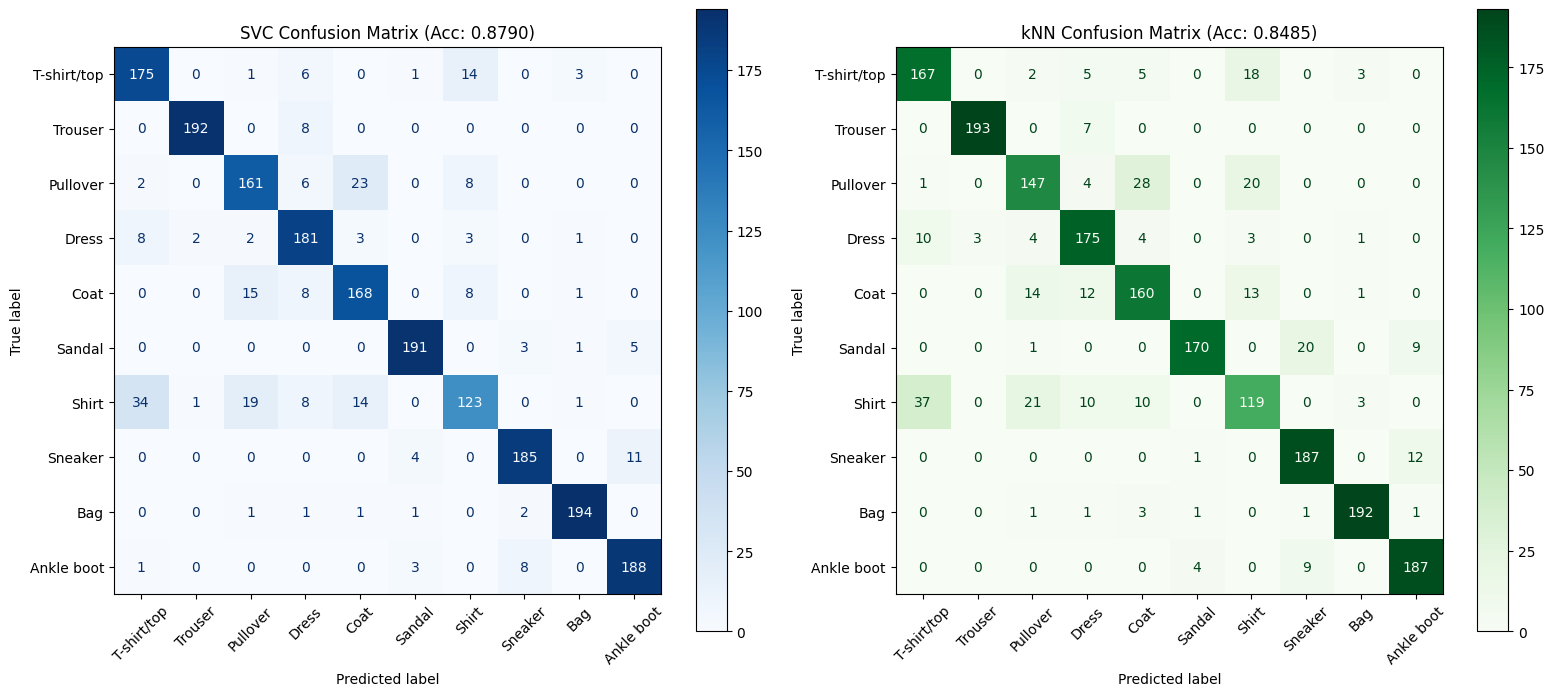

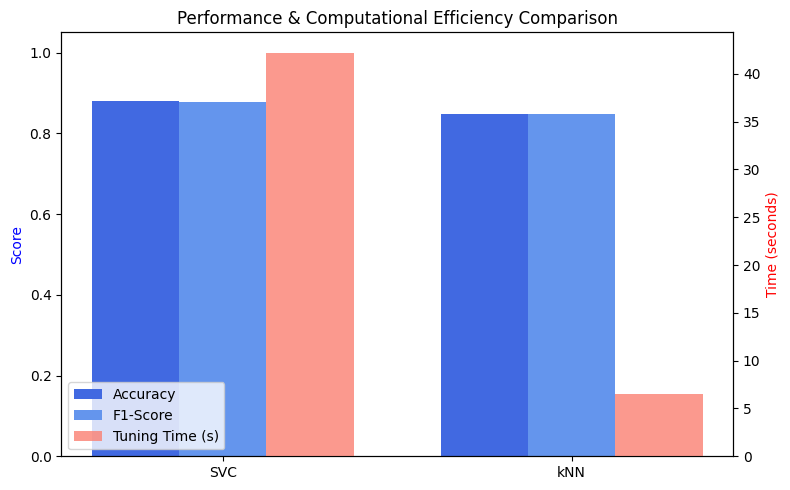

In [7]:
best_svc = svc_grid.best_estimator_
best_knn = knn_grid.best_estimator_

# Predict on test set
start_eval = time.time()
svc_preds = best_svc.predict(X_test_pca)
svc_eval_time = time.time() - start_eval

start_eval = time.time()
knn_preds = best_knn.predict(X_test_pca)
knn_eval_time = time.time() - start_eval

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1 = f1_score(y_test, svc_preds, average='weighted')
knn_acc = accuracy_score(y_test, knn_preds)
knn_f1 = f1_score(y_test, knn_preds, average='weighted')

print("="*60)
print("SUPPORT VECTOR CLASSIFIER (SVC) TEST EVALUATION")
print("="*60)
print(classification_report(y_test, svc_preds, target_names=class_names))

print("="*60)
print("k-NEAREST NEIGHBORS (kNN) TEST EVALUATION")
print("="*60)
print(classification_report(y_test, knn_preds, target_names=class_names))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, svc_preds, display_labels=class_names, 
    cmap='Blues', ax=axes[0], xticks_rotation=45
)
axes[0].set_title(f"SVC Confusion Matrix (Acc: {svc_acc:.4f})")

ConfusionMatrixDisplay.from_predictions(
    y_test, knn_preds, display_labels=class_names, 
    cmap='Greens', ax=axes[1], xticks_rotation=45
)
axes[1].set_title(f"kNN Confusion Matrix (Acc: {knn_acc:.4f})")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_model_confusion_matrices.png"), dpi=150)
plt.show()

# Plot Performance & Training time comparison side-by-side
metrics_df = pd.DataFrame({
    'Model': ['SVC', 'kNN'],
    'Accuracy': [svc_acc, knn_acc],
    'Weighted F1-Score': [svc_f1, knn_f1],
    'Tuning Time (s)': [svc_time, knn_time]
})

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

width = 0.25
ind = np.arange(2)

rects1 = ax1.bar(ind - width/2, metrics_df['Accuracy'], width, label='Accuracy', color='royalblue')
rects2 = ax1.bar(ind + width/2, metrics_df['Weighted F1-Score'], width, label='F1-Score', color='cornflowerblue')
rects3 = ax2.bar(ind + width*1.5, metrics_df['Tuning Time (s)'], width, label='Tuning Time (s)', color='salmon', alpha=0.8)

ax1.set_ylabel('Score', color='blue')
ax2.set_ylabel('Time (seconds)', color='red')
ax1.set_xticks(ind + width/2)
ax1.set_xticklabels(metrics_df['Model'])
ax1.set_ylim(0, 1.05)
ax1.set_title("Performance & Computational Efficiency Comparison")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_model_performance_comparison.png"), dpi=150)
plt.show()

## 7. Model Serialization

We save our pipeline components (the best classifier, the PCA transformer, and meta configurations) as a single serialized joblib artifact for downstream predictions.

In [8]:
MODELS_DIR = "../../models/fashion_classifier"
os.makedirs(MODELS_DIR, exist_ok=True)

best_model_obj = best_svc if svc_acc >= knn_acc else best_knn
best_model_name = "SVC" if svc_acc >= knn_acc else "kNN"

payload = {
    'best_model': best_model_obj,
    'best_model_name': best_model_name,
    'pca_transformer': pca,
    'class_names': class_names,
    'target_resolution': (14, 14),
    'metrics': {
        'svc_accuracy': svc_acc,
        'svc_f1': svc_f1,
        'knn_accuracy': knn_acc,
        'knn_f1': knn_f1
    }
}

joblib.dump(payload, os.path.join(MODELS_DIR, "fashion_classifier_pipeline.joblib"))
print(f"Best model ({best_model_name}) and preprocessing/PCA payload successfully saved to models/fashion_classifier_pipeline.joblib")

Best model (SVC) and preprocessing/PCA payload successfully saved to models/fashion_classifier_pipeline.joblib
